# Playground to manually test a few architectures/hyperparameters
## Train LSTM pipeline and plot rolling forecasts for test profiles

In [1]:
from pathlib import Path

from rabl.machine_learning.lstm_pipeline import (
    LSTMPipeline,
    LSTMPipelineConfig,
    test_and_save_forecasts,
    clear_cuda_cache,
)

In [2]:
batch_size = 256
epochs = 25
seed = 123
max_plots = 5

n_lstm = 2
lstm_hidden = 128              # shared across stacked layers
lstm_dropout = 0.3            # ignored if n_lstm == 1 in nn.LSTM

n_fc = 1
fc_hidden = (64,)

learning_rate = 1e-3


h5_path = Path("../outputs/datasets/lstm_merged_batches_0001_k5_standard_train0.70_val0.15_test0.15.h5")
out_dir = Path("../outputs/ml_results/training_playground/")
out_dir.mkdir(parents=True, exist_ok=True)

print("h5_path exists:", h5_path.exists())
print("out_dir:", out_dir)

h5_path exists: True
out_dir: ..\outputs\ml_results\training_playground


In [3]:
config = LSTMPipelineConfig(
    h5_path=h5_path,
    batch_size=batch_size,
    seed=seed,
    n_lstm=n_lstm,
    lstm_hidden=lstm_hidden,
    lstm_dropout=lstm_dropout,
    n_fc=n_fc,
    fc_hidden=tuple(fc_hidden),
    learning_rate=learning_rate,
)

pipeline = LSTMPipeline(config)

datasets = pipeline.build()
pipeline.inspect()

Dataset summary:
  H5 path:         ..\outputs\datasets\lstm_merged_batches_0001_k5_standard_train0.70_val0.15_test0.15.h5
  Batch size:      256
  Seed:            123

  Train profiles:  700
  Val profiles:    150
  Test profiles:   150

  Sample X shape:  (2001, 6, 14)   (per-sample)
  Sample Y shape:  (2001, 13)   (per-sample)

  Train samples:   1,400,700  (~5,472 batches)
  Val samples:     300,150  (~1,173 batches)
  Test samples:    300,150  (profiles used for forecasting)

  loader cardinality (derived from precomputed counts):
    train:          5472
    val_samples:    1173
    val_profile_ds: 150
    test_profile_ds:150

Train batch X shape: torch.Size([256, 6, 14])
Train batch Y shape: torch.Size([256, 13])

Val profile: results_drum_profile_00008
  X profile shape: torch.Size([2001, 6, 14])
  Y profile shape: torch.Size([2001, 13])

Test profile: results_drum_profile_00004
  X profile shape: torch.Size([2001, 6, 14])
  Y profile shape: torch.Size([2001, 13])



Using GPU: NVIDIA GeForce RTX 4060 Ti

LSTMRegressor architecture:
  Input features: 14
  LSTM layers (2): hidden_size=256, dropout=0.3
  FC layers (1): [64]
  Output targets: 13



Train 1/25: 5472batch [00:26, 209.93batch/s, loss=0.002900]
Val 1/25: 1173batch [00:03, 381.96batch/s]


Epoch 1/25 - loss: 0.022299 - val_loss: 0.030475 - data_time: 0.00s - compute_time: 12.90s - val_time: 3.07s - max_cuda_mem: 66.87 MB


Train 2/25: 5472batch [00:26, 210.12batch/s, loss=0.003214]
Val 2/25: 1173batch [00:02, 399.12batch/s]


Epoch 2/25 - loss: 0.007082 - val_loss: 0.020913 - data_time: 0.00s - compute_time: 12.88s - val_time: 2.94s - max_cuda_mem: 66.87 MB


...

Epoch 23/25 - loss: 0.001127 - val_loss: 0.002706 - data_time: 0.00s - compute_time: 12.50s - val_time: 3.01s - max_cuda_mem: 66.87 MB


Train 24/25: 5472batch [00:25, 215.95batch/s, loss=0.000974]
Val 24/25: 1173batch [00:02, 395.22batch/s]


Epoch 24/25 - loss: 0.001070 - val_loss: 0.006495 - data_time: 0.00s - compute_time: 12.42s - val_time: 2.97s - max_cuda_mem: 66.87 MB


Train 25/25: 5472batch [00:26, 209.73batch/s, loss=0.000243]
Val 25/25: 1173batch [00:03, 384.59batch/s]


Epoch 25/25 - loss: 0.001161 - val_loss: 0.002833 - data_time: 0.00s - compute_time: 12.89s - val_time: 3.05s - max_cuda_mem: 66.87 MB
Saved training curves to ..\outputs\ml_results\training_playground\lstm_train_val_curve.png
Finished training using device: cuda:0


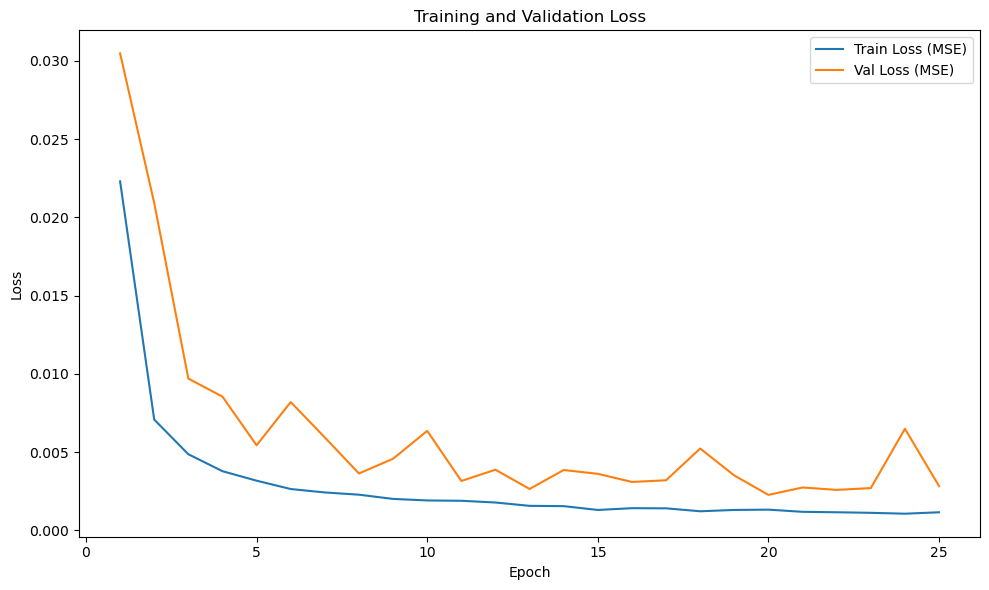

In [4]:
model, history, used_device = pipeline.train(epochs=epochs, out_dir=out_dir)
print(f"Finished training using device: {used_device}")

In [5]:
test_and_save_forecasts(
    model,
    datasets["test_profile_ds"],
    out_dir=out_dir,
    state_dim=pipeline.config.state_dim,
    control_channel=pipeline.config.control_channel,
    target_names=pipeline.config.target_names,
    max_plots=max_plots,
    plot_callback=pipeline.plot,
    h5_path=h5_path,
)

if "cuda" in str(used_device).lower():
    print(f"Clearing {used_device}...")
    del model
    clear_cuda_cache()

Forecast profiles: 1profile [00:02,  2.53s/profile, mse=1.390028e+09]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00004.png


Forecast profiles: 2profile [00:05,  2.58s/profile, mse=1.687339e+09]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00006.png


Forecast profiles: 3profile [00:07,  2.56s/profile, mse=2.135918e+09]

...

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00025.png


Forecast profiles: 5profile [00:12,  2.57s/profile, mse=1.961451e+09]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00028.png


Forecast profiles: 102profile [02:08,  1.26s/profile, mse=1.479204e+09]


KeyboardInterrupt: 